In [103]:
import lics_tstools as lts
import os
import glob
from lics_unwrap import *
frame='123D_05095_141313'
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia')



False
No, here I am
assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


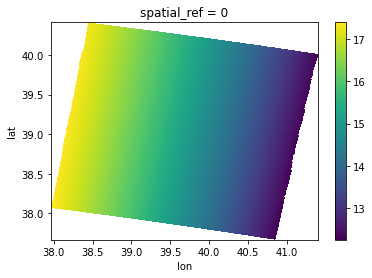

In [104]:
vlos_eurasia.plot()

In [105]:
vazi_eurasia = generate_pmm_velocity(frame, 'Eurasia', sboi=True)


True
here I am
assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


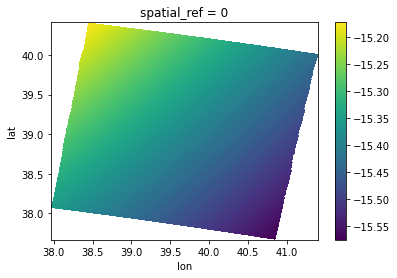

In [107]:
vazi_eurasia.plot()

In [47]:
def load_metatif(keystr='U', geocdir='GEOC', frame=None):
    '''set either geocdir or frame ID (if to use LiCSAR data) to load one of: U, E, N, hgt, landmask (as keystr)'''
    M = None
    if geocdir:
        M = glob.glob(geocdir + '/*.geo.' + keystr + '.tif')
    if M:
        M = M[0]
    elif frame:
        metadir = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
        M = os.path.join(metadir, frame + '.geo.' + keystr + '.tif')
        if not os.path.exists(M):
            M = None
    if M:
        M = load_tif2xr(M)
        M = M.where(M != 0)
        return M
    else:
        print('ERROR: no ' + keystr + ' layer exists')
        return False

In [98]:
def generate_pmm_velocity(frame, plate = 'Eurasia', geocdir = None, outif = None, sboi=False):
    '''This will generate LOS velocity for selected tectonic plate, such as for absolute referencing towards Eurasia..
    uses MintPy functionality that implements velocity calculation using Euler poles rather than plate motion model with plates defined as polygons.

    For all codes, see licsbas_mintpy_PMM
    If geocdir is None, it will search directly on LiCSAR system (if you run this on JASMIN..)
    '''
    import licsbas_mintpy_PMM as pmm
    sampling = 20000  # m --- note, this is only primary sampling, we will then interpolate to fit the frame data

    # getting plate data
    plate = pmm.ITRF2014_PMM[plate]
    pole_obj = pmm.EulerPole(
        wx=plate.omega_x,
        wy=plate.omega_y,
        wz=plate.omega_z,
        unit='mas/yr',
    )
    # pole_obj.print_info()
    
    # getting the frame data
    print(sboi)
    if sboi:
        print('PMM calculation in azimuth direction')
        E = load_metatif('E.azi', geocdir, frame)
        N = load_metatif('N.azi', geocdir, frame)
        U = load_metatif('U.azi', geocdir, frame)
        print('here I am')
    else:
        print('PMM calculation in range direction')
        E = load_metatif('E', geocdir, frame)
        N = load_metatif('N', geocdir, frame)
        U = load_metatif('U', geocdir, frame)
    # coarsening unit vector U as template for the plate velocity
    resolution = get_resolution(U, in_m=True)  # just mean avg in both lon, lat should be ok
    # how large area is covered
    lonextent = len(U.lon) * resolution
    # so what is the multilook factor?
    mlfactorlon = round(len(U.lon) / (lonextent / sampling))
    latextent = len(U.lat) * resolution
    mlfactorlat = round(len(U.lat) / (latextent / sampling))
    Uml = U.coarsen({'lat': mlfactorlat, 'lon': mlfactorlon}, boundary='trim').mean()

    lats = []
    lons = []
    for i in range(len(Uml.lat.values)):
        for j in range(len(Uml.lon.values)):
            lats.append(Uml.lat.values[i])
            lons.append(Uml.lon.values[j])
    lats = np.array(lats)
    lons = np.array(lons)

    # finally getting the plate velocities from the Euler pole definition over the frame area
    ve, vn, vu = pole_obj.get_velocity_enu(lats, lons, alt=0.0, ellps=True)

    # 1. interpolate the plate vel enus (i know, 3x more work here but still .. reasonable due to nans in ENU etc.)
    print('Interpolating the plate velocity ENU vectors to the original frame resolution')
    Uml.values = ve.reshape(Uml.shape)
    ve = Uml.interp_like(U, method='linear', kwargs={"fill_value": "extrapolate"})
    Uml.values = vn.reshape(Uml.shape)
    vn = Uml.interp_like(U, method='linear', kwargs={"fill_value": "extrapolate"})
    Uml.values = vu.reshape(Uml.shape)
    vu = Uml.interp_like(U, method='linear', kwargs={"fill_value": "extrapolate"})

    # 2.
    print('Calculating the plate motion velocity in LOS (please check the sign here)')
    if sboi:
        vlos_plate = ve*E + vn*N
    else:
        vlos_plate = ve*E + vn*N + vu*U
    vlos_plate = 1000*vlos_plate # to mm/year
    if outif:
        export_xr2tif(vlos_plate, outif, dogdal = False)
    return vlos_plate

In [23]:
metadir= os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
M = os.path.join(metadir, frame + '.geo.' + 'E' + '.tif')
if not os.path.exists(M):
    M = None

In [24]:
M

'/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products/123/123D_05095_141313/metadata/123D_05095_141313.geo.E.tif'

In [ ]:
# sys.exit()
# #else:
# #    vlos_eurasia = lts.load_tif2xr(vlos_eurfile)
# vel_tiffile = tsdir+'/results/vel.filt.mskd.tif'
# # if not os.path.exists(vel_tiffile):   # why not to regenerate it....
# cmd = 'LiCSBAS_flt2geotiff.py -i {0}/results/vel.filt.mskd -p {0}/info/EQA.dem_par -o {0}/results/vel.filt.mskd.tif'.format(tsdir)
# os.system(cmd)
# if not os.path.exists(vel_tiffile):
#     print('ERROR, cannot generate vlos tif file')
#     exit()

# vlos = lts.load_tif2xr(vel_tiffile)
# vlos_eurasia_reshaped = vlos_eurasia.interp_like(vlos)

# vlos.values = vlos.values - vlos_eurasia_reshaped.values
# if not keep_absolute:
#     print('\n Fixing to the reference area selected at step 16 \n')
#     infodir = os.path.join(tsdir, 'info')
#     reffile = os.path.join(infodir, '16ref.txt')
#     if not os.path.exists(reffile):
#         print('ERROR, no 16ref.txt file exists! Referring to the median of whole scene instead \n')
#         vlos = vlos - vlos.where(vlos != 0).median()
#     else:
#         with open(reffile, "r") as f:
#             refarea = f.read().split()[0]  # str, x1/x2/y1/y2
#         refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]
#         vlos.values = vlos.values - np.nanmean(vlos.values[refy1:refy2, refx1:refx2])
# lts.export_xr2tif(vlos, outfile, dogdal = False)

# # %% Make png if specified
# if pngflag:
#     pngfile = outfile[:-4] + '.png'
#     title = 'Velocity fixed towards Eurasia'
#     cmin = np.nanpercentile(vlos.values, 1)
#     cmax = np.nanpercentile(vlos.values, 99)
#     plot_lib.make_im_png(vlos.values, pngfile, cmap, title, cmin, cmax)

#     pngfile = vlos_eurfile[:-4] + '.png'
#     title = 'Eurasia-fixed plate motion'
#     cmin = np.nanpercentile(vlos_eurasia.values, 1)
#     cmax = np.nanpercentile(vlos_eurasia.values, 99)
#     plot_lib.make_im_png(vlos_eurasia.values, pngfile, cmap, title, cmin, cmax)

# if vstd_fix:
#     # recalc vstd
#     #if not os.path.exists(tsdir+'/results/vstd.tif'):
#     print('generating vstd tif')
#     cmd = 'LiCSBAS_flt2geotiff.py -i {0}/results/vstd -p {0}/info/EQA.dem_par -o {0}/results/vstd.tif'.format(tsdir)
#     os.system(cmd)
#     #
#     print('updating vstd (removing reference effect)')
#     cmd = 'cd {0}/results; LiCSBAS_remove_reference_effect_from_vstd.py'.format(tsdir)
#     os.system(cmd)



# #%% Finish
# elapsed_time = time.time()-start
# hour = int(elapsed_time/3600)
# minite = int(np.mod((elapsed_time/60),60))
# sec = int(np.mod(elapsed_time,60))
# print("\nElapsed time: {0:02}h {1:02}m {2:02}s".format(hour,minite,sec))

# print('\n{} Successfully finished!!\n'.format(os.path.basename(argv[0])))
# print('Output: {}\n'.format(outfile), flush=True)


# #%% main
# if __name__ == "__main__":
# sys.exit(main())
